#Preparación

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

In [6]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Carga y exploración inicial

##Carga

In [8]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Fundamentos de Ciencia de Datos/inversiones.csv", sep=";", encoding="latin-1", on_bad_lines="skip")

In [9]:
df.head(3)

,Ano,Departamento,gabinete,sector,subsector,institucion,proyecto,monto,Unnamed: 8
0,2019,Atlántida,"Gabinete de Infraestructura, Servicios y Empr",Agroforestal y Turismo,Desarrollo Productivo,Cuenta del Desafío del Milenio-Honduras,"PROYECTO DE COMPETITIVIDAD RURAL EN HONDURAS, ...",69711066.0,NaN
1,2019,Atlántida,"Gabinete de Infraestructura, Servicios y Empr",Promoción y Protección Humana,Protección Social,Cuenta del Desafío del Milenio-Honduras,Centros de Atención Integral para mejorar las ...,54938971.0,NaN
2,2019,Atlántida,"Gabinete de Infraestructura, Servicios y Empr",Promoción y Protección Humana,Protección Social,Fondo Hondureño de Inversión Social,PROGRAMA DE INFRAESTRUCTURA PARA LA SEGURIDAD ...,47080712.0,NaN


##Info, dimensiones y columnas

In [10]:
print(f"Las dimensiones del arreglo son: {df.shape}")

Las dimensiones del arreglo son: (2380, 9)


In [11]:
print(f"El arreglo tiene datos sobre las siguientes variables: \n\n{df.columns}")

El arreglo tiene datos sobre las siguientes variables: 

Index(['Ano', 'Departamento', 'gabinete', 'sector', 'subsector', 'institucion',
       'proyecto', 'monto', 'Unnamed: 8'],
      dtype='object')


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2380 entries, 0 to 2379
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ano           2380 non-null   int64  
 1   Departamento  2380 non-null   object 
 2   gabinete      1648 non-null   object 
 3   sector        2021 non-null   object 
 4   subsector     2021 non-null   object 
 5   institucion   2380 non-null   object 
 6   proyecto      2380 non-null   object 
 7   monto         2380 non-null   float64
 8   Unnamed: 8    0 non-null      float64
dtypes: float64(2), int64(1), object(6)
memory usage: 167.5+ KB


#Limpieza de datos

##Columna `Unnamed: 8`

In [13]:
df = df.drop(columns=["Unnamed: 8"])
df.shape

(2380, 8)

Encontramos la columna 'Unnamed: 8' que solo tiene valores NaN, por lo que la eliminamos. Esto cambia tamaño a 2380 filas por 8 columnas.

##Valores nulos

In [14]:
print("Valores faltantes por columna:")
print(df.isnull().sum())

Valores faltantes por columna:
Ano               0
Departamento      0
gabinete        732
sector          359
subsector       359
institucion       0
proyecto          0
monto             0
dtype: int64


En vista de que hay muchos valores faltantes, se podría perder mucha información al eliminarlos todos, por lo que solo se eliminarán datos si falta un valor crítico: 'Ano', 'monto' y 'Departamento'.

##Registros duplicados

In [15]:
print("Conteo de proyectos duplicados")
print(df.duplicated().sum())

Conteo de proyectos duplicados
0


No se encuentran registros duplicados, por ende no se hace ninguna modificación.

##Revisión variables categóricas

###Departamento

In [16]:
col = "Departamento"
print(f"Cantidad de valores unicos: {df[col].nunique()}")
print(df[col].unique())

Cantidad de valores unicos: 46
['Atlántida' 'Choluteca' 'Colón' 'Comayagua' 'Copán' 'Cortés' 'El Paraíso'
 'Francisco Morazán' 'Gracias a Dios' 'Intibucá' 'Islas de la Bahía'
 'La Paz' 'Lempira' 'Ocotepeque' 'Olancho' 'Santa Bárbara' 'Valle' 'Yoro'
 'Sin Asignar' 'Copan' 'Santa Barbara' 'COPÁN' 'CORTÉS'
 'FRANCISCO MORAZÁN' 'INTIBUCA' 'LA PAZ' 'LEMPIRA' 'OCOTEPEQUE'
 'SANTA BÁRBARA' 'ATLÁNTIDA' 'CHOLUTECA' 'GRACIAS A DIOS' 'COLÓN'
 'COMAYAGUA' 'EL PARAISO' 'ISLAS DE LA BAHÍA' 'OLANCHO' 'VALLE' 'YORO'
 'Cortes' 'Islas de la Bahia' 'ATLANTIDA' 'CORTES' 'FRANCISCO MORAZAN'
 'ISLAS DE LA BAHIA' 'SANTA BARBARA']


Observamos 46 valores únicos para el departamento. Corregimos el formato y la acentuación para asegurar consistencia. También eliminamos la categoría 'Sin Asignar' ya que 'Departamento' es un factor crítico en esta investigación. Se eliminan 4 registros.

In [17]:
correcciones = { #Correciones por acentuación
    "atlantida": "atlántida",
    "copan": "copán",
    "cortes": "cortés",
    "el paraiso": "el paraíso",
    "francisco morazan": "francisco morazán",
    "intibuca": "intibucá",
    "islas de la bahia": "islas de la bahía",
    "santa barbara": "santa bárbara"
}

df["Departamento"] = df["Departamento"].str.strip() #Eliminamos espacios al final del string
df["Departamento"] = df["Departamento"].str.lower() #Convertimos todo a minúscula
df["Departamento"] = df["Departamento"].replace(correcciones) #Corregimos departamentos sin tilde
df["Departamento"] = df["Departamento"].str.title() #Formato de título (Cada palabra comienza en mayúscula)
df = df[df["Departamento"] != "Sin Asignar"] #Eliminamos el departamento 'Sin Asignar'

In [18]:
col = "Departamento"
print(f"Cantidad de valores unicos: {df[col].nunique()}")
print(df[col].unique())

Cantidad de valores unicos: 18
['Atlántida' 'Choluteca' 'Colón' 'Comayagua' 'Copán' 'Cortés' 'El Paraíso'
 'Francisco Morazán' 'Gracias A Dios' 'Intibucá' 'Islas De La Bahía'
 'La Paz' 'Lempira' 'Ocotepeque' 'Olancho' 'Santa Bárbara' 'Valle' 'Yoro']


In [19]:
df.shape

(2376, 8)

###Sector

In [20]:
col = "sector"
print(f"Cantidad de valores unicos: {df[col].nunique()}")
print(df[col].unique())

Cantidad de valores unicos: 21
['Agroforestal y Turismo' 'Promoción y Protección Humana'
 'Comunicaciones y Energía' 'Fortalecimiento Institucional'
 'FORTALECIMIENTO INSTITUCIONAL' 'AGROFORESTAL Y TURISMO'
 'PROMOCION Y PROTECCION HUMANA' 'COMUNICACIONES Y ENERGIA' nan
 'PROMOCIÓN Y PROTECCIÓN HUMANA' 'COMUNICACIONES Y ENERGÍA'
 'FORTALECIMIENTO INSTITUCIONAL ' '1 - PROMOCION Y PROTECCION HUMANA'
 '2 - COMUNICACIONES Y ENERGIA' '3 - AGROFORESTAL Y TURISMO'
 '4 - FORTALECIMIENTO INSTITUCIONAL' 'No está definido' '(en blanco)'
 ' COMUNICACIONES Y ENERGIA' ' PROMOCION Y PROTECCION HUMANA'
 ' FORTALECIMIENTO INSTITUCIONAL' ' AGROFORESTAL Y TURISMO']


Observamos:<br>
1. Problemas de acentuación
2. Problemas de formato
3. Categorías no útiles

Se eliminan 4 registros.

In [21]:
correcciones_sector = { #Correcciones por acentuación
    "promocion y proteccion humana": "promoción y protección humana",
    "comunicaciones y energia": "comunicaciones y energía"
}


df["sector"] = df["sector"].str.strip() #Eliminar espacios
df["sector"] = df["sector"].str.replace(r"^\d+\s-\s", "", regex=True) #Eliminar códigos numéricos
df["sector"] = df["sector"].str.lower() #Convertir a minúsculas
df["sector"] = df["sector"].replace(correcciones_sector) #Correcciones por acentuación
df["sector"] = df["sector"].str.title() #Formato de título
df = df[~df["sector"].isin(["No Está Definido", "(En Blanco)"])] #Eliminamos valores en categorías no útiles
df["sector"] = df["sector"].fillna("No Definido") #Cambiar NaNs por 'No Definido'

###Subsector

In [22]:
col = "subsector"
print(f"Cantidad de valores unicos: {df[col].nunique()}")
print(df[col].unique())

Cantidad de valores unicos: 41
['Desarrollo Productivo' 'Protección Social' 'Carreteras' 'Educación'
 'Salud' 'Energía' 'Recursos Forestal Y Ambie' 'Modernización Del Estado'
 'Seguridad Y Defensa' 'Riego' 'Descentralización' 'Comunicaciones'
 'MODERNIZACION DEL ESTADO' 'RECURSOS FORESTAL Y AMBIENTE' 'EDUCACION'
 'DESARROLLO PRODUCTIVO' 'RIEGO' 'PROTECCION SOCIAL' 'SEGURIDAD Y DEFENSA'
 'CARRETERAS' 'TRANSPORTE Y OBRAS PUBLICAS' 'ENERGIA' 'COMUNICACIONES'
 'Recursos Forestales y Ambiente' 'SALUD' nan 'AGUA Y SANEAMIENTO'
 'PROTECCIÓN SOCIAL' 'EDUCACIÓN' 'DESARROLLO PRODUCTIVO Y RIEGO'
 'AGUA Y SANEAMIENTO ' 'MODERNIZACIÓN DEL ESTADO'
 'FORTALECIMIENTO INSTITUCIONAL' 'ENERGÍA' 'FORESTAL '
 'SEGURIDAD ALIMENTARIA' 'FORESTAL' 'TRANSPORTE Y OBRAS PÚBLICAS' '0'
 'ARTES Y CULTURA ' 'DEPORTES' 'DESCENTRALIZACION']


Observamos subsectores que representan lo mismo con diferencias por acentuación, valores con '0' (considerados inválidos).

In [23]:
correcciones_subsector = { #Correcciones por acentuación
    "educacion": "educación",
    "proteccion social": "protección social",
    "modernizacion del estado": "modernización del estado",
    "energia": "energía",
    "descentralizacion": "descentralización",
    "recursos forestal y ambiente": "recursos forestales y ambiente",
    "transporte y obras publicas": "transporte y obras públicas"
}

df["subsector"] = df["subsector"].str.strip() # Eliminar espacios al final del texto
df["subsector"] = df["subsector"].str.lower() # Convertir todo a minúsculas
df["subsector"] = df["subsector"].replace(correcciones_subsector) # Ejecutar correcciones por acentuación

df["subsector"] = df["subsector"].replace({ # Unificar categorías que representan lo mismo
    "desarrollo productivo y riego": "desarrollo productivo",
    "forestal": "recursos forestales y ambiente",
    "recursos forestal y ambie": "recursos forestales y ambiente"
})

df["subsector"] = df["subsector"].str.title() #Convertir a formato título
df["subsector"] = df["subsector"].replace("0", np.nan) # Reemplazar valores inválidos por NaN (aparecen valores como "0")
df["subsector"] = df["subsector"].fillna("No Definido") #Reemplazar valores faltantes por 'No Definido'

###Gabinete

In [24]:
col = "gabinete"
print(f"Cantidad de valores unicos: {df[col].nunique()}")
print(df[col].unique())

Cantidad de valores unicos: 17
['Gabinete de Infraestructura, Servicios y Empr' 'Gabinete Social'
 'Gabinete Económico' 'Entes Adscritos a la Presidencia de la Repúbl'
 'Gabinete de Prevención, Seguridad y Defensa'
 'Entes sin Adscripción a un Gabinete Sectorial'
 'Entes que no forman parte del Poder Ejecutivo'
 'Gabinete de Gobernabilidad'
 'Gabinete Sectorial de Infraestructura Servicios y Empresas Públicas'
 'Gabinete Sectorial de Seguridad y Defensa' nan
 'Gabinete de Infraestructura Productiva'
 'Gabinete de Seguridad y Defensa'
 'Gabinete de Conducción y Regulación Económico'
 'Gabinete Desarrollo e Inclusión' 'Gabinete de Desarrollo Económico'
 'No aplica' 'No Aplica']


Observamos que gabinete presenta similares problemas de acentuación y categorías separadas que significan lo mismo. Los valores NA se cambian por 'No Definido'.

In [25]:
df["gabinete"] = df["gabinete"].str.strip() #Eliminar espacios al final del texto
df["gabinete"] = df["gabinete"].replace({ #Unificar valores que representan lo mismo
    "No Aplica": "No aplica"
})
df["gabinete"] = df["gabinete"].str.lower() # Convertir todo a minúscula
df["gabinete"] = df["gabinete"].str.title() # Volver a formato título
df["gabinete"] = df["gabinete"].fillna("No Definido") # Reemplazar valores faltantes por 'No Definido'

###Institución

In [26]:
col = "institucion"
print(f"Cantidad de valores unicos: {df[col].nunique()}")
print(df[col].unique())

Cantidad de valores unicos: 102
['Cuenta del Desafío del Milenio-Honduras'
 'Fondo Hondureño de Inversión Social'
 'Secretaría de Desarrollo e Inclusión Social' 'Secretaría de Educación'
 'Secretaría de Salud' 'Secretaría de Agricultura y Ganadería'
 'Empresa Nacional de Energía Eléctrica'
 'Instituto Nacional de Conservación y Desarrollo Forestal'
 'Secretaría de Finanzas' 'Secretaría de Trabajo y Seguridad Social'
 'Secretaría de Infraestructura y Servicios Públicos'
 'Programa Nacional de Desarrollo Rural y Urbano Sostenible'
 'Servicio de Administración de Rentas'
 'Universidad Pedagógica Nacional Francisco Morazán'
 'Dirección Nacional del Programa Ciudad Mujer' 'Secretaría de Seguridad'
 'Secretaría de Coordinación General del Gobierno' 'Poder Judicial'
 'Instituto Hondureño de Ciencia, Tecnología e Innovación'
 'Instituto Nacional Agrario' 'Empresa Hondureña de Telecomunicaciones'
 'Comisión Permanente de Contingencias'
 'Universidad Nacional de Agricultura'
 'Centro Nacional de

Observamos que institucion presenta similares problemas de acentuación y categorías separadas que significan lo mismo. Los valores NA se cambian por 'No Definido'.

In [27]:
correcciones_institucion = { #Correcciones por acentuación
    "sectetaria de salud": "secretaria de salud",
    "universiad nacional de agricultura": "universidad nacional de agricultura",
    "dministración nacional de servicio civil": "administración nacional de servicio civil",
    "secretaria de finanzas": "secretaría de finanzas",
    "secretaria de educacion": "secretaría de educación",
    "secretaria de seguridad": "secretaría de seguridad",
    "secretaria de trabajo y seguridad social": "secretaría de trabajo y seguridad social",
    "secretaria de agricultura y ganaderia": "secretaría de agricultura y ganadería",
    "secretaria de infraestructura y servicios publicos": "secretaría de infraestructura y servicios públicos",
    "secretaria de desarrollo e inclusión social": "secretaría de desarrollo e inclusión social",
    "direccion nacional del programa de ciudad mujer": "dirección nacional del programa ciudad mujer",
    "empresa nacional de energia electrica": "empresa nacional de energía eléctrica",
    "servicio de administracion de rentas": "servicio de administración de rentas",
    "instituto nacional de conservacion y desarrollo forestal": "instituto nacional de conservación y desarrollo forestal",
    "inversion estrategica de honduras (invest-honduras)": "inversión estratégica de honduras (invest-honduras)",
    "alcaldia municipal del distrito central": "alcaldía municipal del distrito central",
    "instituto hondureño de mercadeo agricola": "instituto hondureño de mercadeo agrícola",
    "registro nacional de las personas": "registro nacional de las personas",
    "secretaría de infraestructura y transporte": "secretaría de infraestructura y transporte",
    "programa de la red solidaria": "red solidaria"
}

df["institucion"] = df["institucion"].str.strip() #Eliminar espacios al final
df["institucion"] = df["institucion"].str.replace(r"^\d+\s*-\s*", "", regex=True) #Eliminar códigos al inicio
df["institucion"] = df["institucion"].str.replace(r"\s+", " ", regex=True) #Eliminar espacios dobles dentro del texto
df["institucion"] = df["institucion"].str.lower() #Convertir todo a minúscula
df["institucion"] = df["institucion"].replace(correcciones_institucion) #Aplicar correcciones de acentuación

df["institucion"] = df["institucion"].replace({ #Unificar duplicados claros
    "fondo hondureño de inversion social": "fondo hondureño de inversión social",
    "secretaría de finanzas": "secretaría de finanzas",
    "secretaría de educación": "secretaría de educación",
    "secretaría de salud": "secretaría de salud",
    "secretaría de seguridad": "secretaría de seguridad",
    "empresa nacional portuaria": "empresa nacional portuaria",
    "hospital escuela universitario": "hospital escuela universitario",
    "universidad nacional de agricultura": "universidad nacional de agricultura"
})

df["institucion"] = df["institucion"].str.title() #Convertir a formato título

##Consistencia temporal

In [28]:
sorted(df["Ano"].unique())

[np.int64(2019),
 np.int64(2020),
 np.int64(2021),
 np.int64(2022),
 np.int64(2023),
 np.int64(2024),
 np.int64(2025)]

Observamos que los proyectos están en un rango esperado (2019 - 2025) sin categorías atípicas. No se realizan cambios.

#Guardado de datos limpios

In [29]:
# Para reproducibilidad
#df.to_csv("inversiones_limpio.csv", index=False)

#Análisis exploratorio

In [30]:
df["monto"].describe()

,monto
count,2.371000e+03
mean,5.477496e+07
std,1.575786e+08
min,0.000000e+00
25%,2.639999e+06
50%,1.183728e+07
75%,4.076007e+07
max,2.970184e+09


##Inversión por departamento

In [31]:
inv_departamento = df.groupby("Departamento")["monto"].sum().sort_values(ascending=False)
inv_departamento

,monto
Departamento,
Francisco Morazán,4.274059e+10
Cortés,2.118532e+10
Santa Bárbara,7.598089e+09
Copán,6.607019e+09
Yoro,6.214677e+09
Olancho,5.939820e+09
El Paraíso,5.836640e+09
Comayagua,5.821034e+09
Choluteca,4.414456e+09


##Inversión por sector

In [33]:
inv_sector = df.groupby("sector")["monto"].sum().sort_values(ascending=False)
inv_sector

,monto
sector,
Comunicaciones Y Energía,5.517400e+10
Promoción Y Protección Humana,4.008212e+10
Agroforestal Y Turismo,1.547703e+10
No Definido,1.056354e+10
Fortalecimiento Institucional,8.574745e+09


##Inversión anual

In [35]:
inv_anual = df.groupby("Ano")["monto"].sum()
inv_anual

,monto
Ano,
2019,1.105321e+10
2020,1.262148e+10
2021,1.056354e+10
2022,1.011618e+10
2023,2.159273e+10
2024,3.510763e+10
2025,2.881667e+10


#Análisis principal

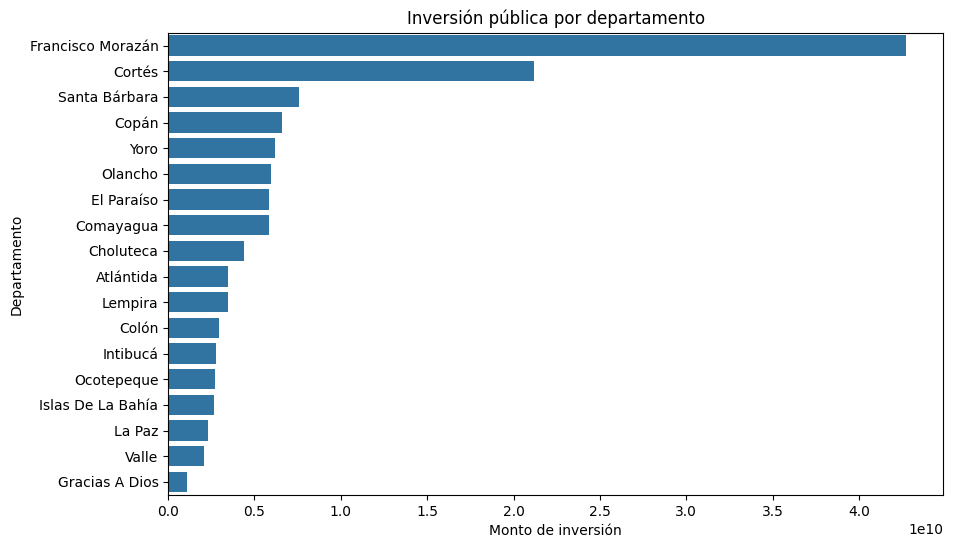

In [32]:
plt.figure(figsize=(10,6))
sns.barplot(x=inv_departamento.values, y=inv_departamento.index)
plt.title("Inversión pública por departamento")
plt.xlabel("Monto de inversión")
plt.ylabel("Departamento")
plt.show()

Observamos que la inversión es mucho mayor en Francisco Morazán que en otros departamentos, recibiendo más de el doble de la inversión que se le da al siguiente departamento en la lista y hasta 38 veces más que el departamento con menos inversión.

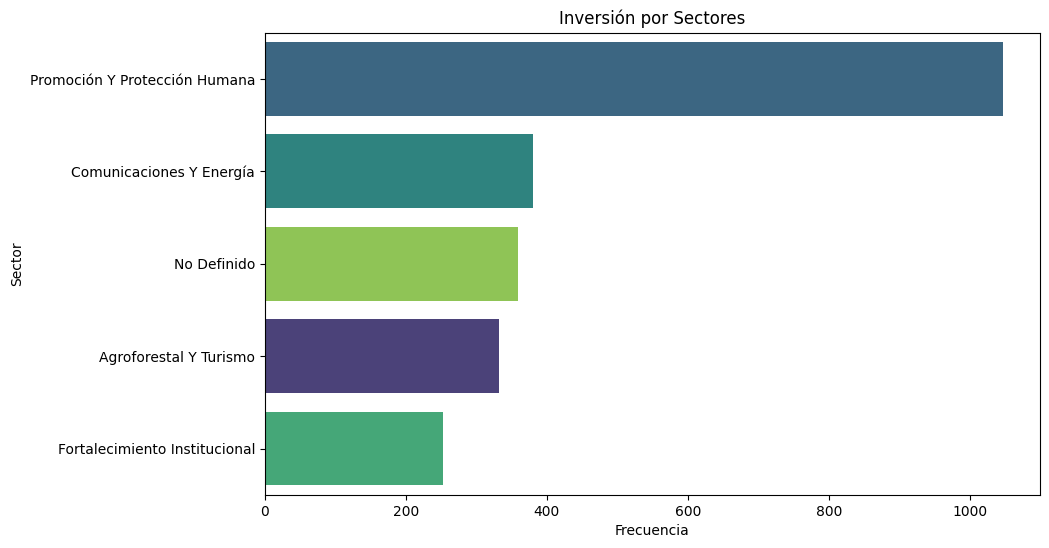

In [45]:
sectores = df['sector'].value_counts().head(10).index

plt.figure(figsize=(10, 6))

sns.countplot(
    y='sector',
    data=df,
    order=sectores,
    palette='viridis',
    hue='sector',
    legend=False
)

plt.title("Inversión por Sectores")
plt.xlabel("Frecuencia")
plt.ylabel("Sector")
plt.show()

Notamos una gran inversión en el sector de Promoción Y Protección Humana, pero también notamos una cantidad considerable en proyectos con un sector no definido.

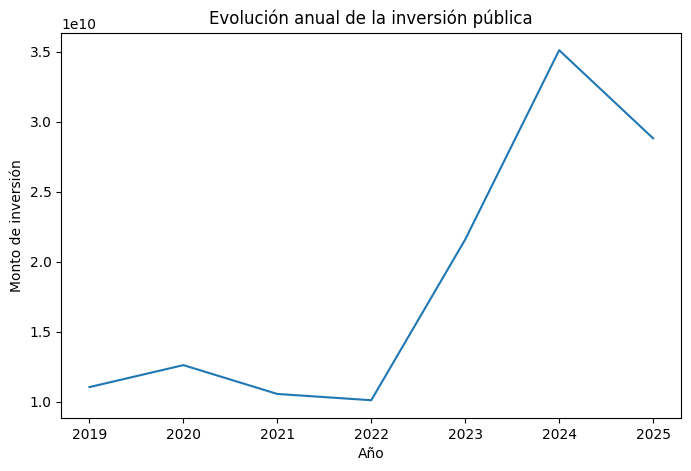

In [46]:
plt.figure(figsize=(8,5))
sns.lineplot(x=inv_anual.index, y=inv_anual.values)
plt.title("Evolución anual de la inversión pública")
plt.xlabel("Año")
plt.ylabel("Monto de inversión")
plt.show()

Notamos que a partir del año 2022 hubo un incremento en la inversión social que se mantuvo en crecimiento hasta el 2024.

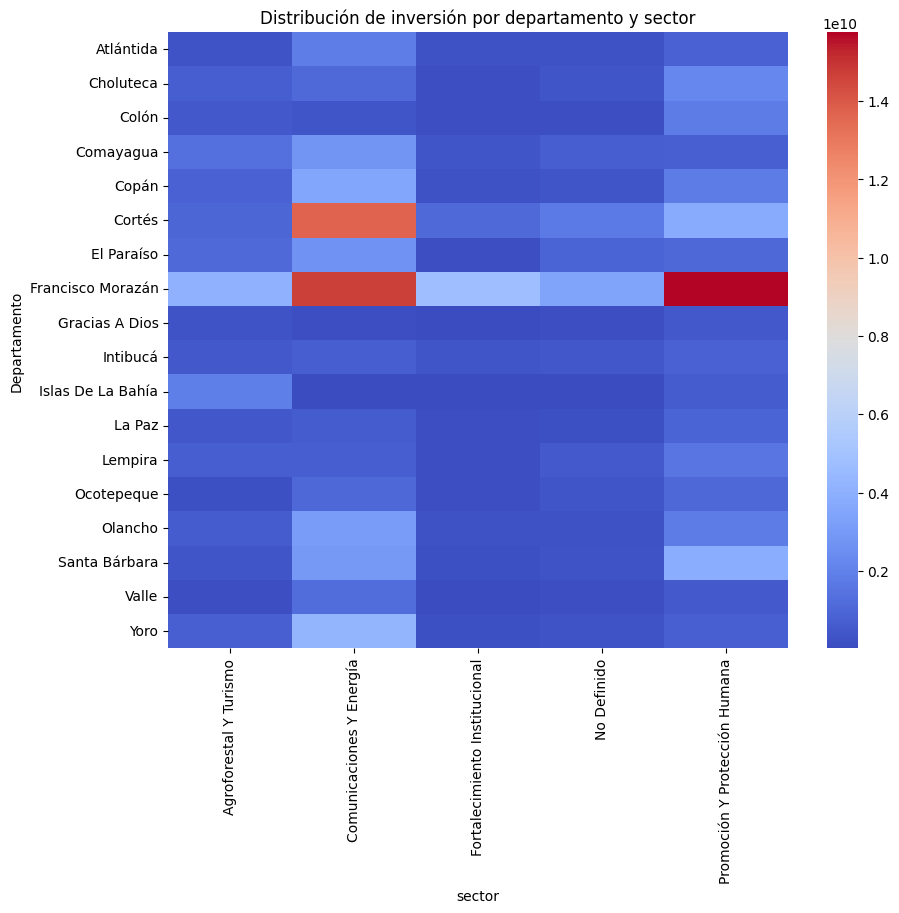

In [37]:
tabla = df.pivot_table(values="monto",
                       index="Departamento",
                       columns="sector",
                       aggfunc="sum")

plt.figure(figsize=(10,8))
sns.heatmap(tabla, cmap="coolwarm")
plt.title("Distribución de inversión por departamento y sector")
plt.show()

Francisco Morazán y Cortés son los departamentos con mayor inversión y notamos que la mayor parte de ese dinero se invierte en comunicaciones y energía y promoción y protección humana.

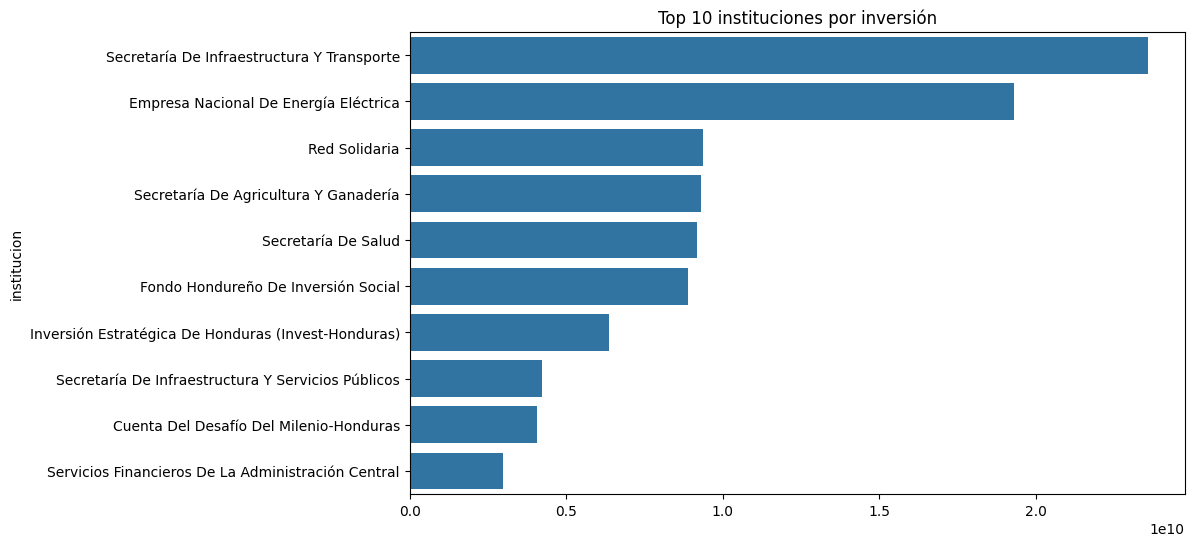

In [39]:
top_inst = df.groupby("institucion")["monto"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_inst.values, y=top_inst.index)
plt.title("Top 10 instituciones por inversión")
plt.show()

1. La secretaría de infraestructura y transporte y la secretaría de energía son las instituciones que más invierten.
2. Combinadas esas dos instituciones se invierte casi lo mismo que las otras 8 combinadas.
3. La secretaría de salud se encuentra en el puesto 5, muy por debajo de otras instituciones menos importantes.